[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_3/03A-Metrics.ipynb)

# 03A — Metrics: choosing what to measure
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 3, Notebook A — Hour 1**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

Class 2 fitted models and reported a number for each: a mean squared error, an $R^2$, an accuracy.
Each time, the number was chosen without much discussion.

That choice deserves the discussion. A metric is not a neutral readout of quality — it is a
statement about which mistakes you mind. Two models can be ranked in opposite orders by two
defensible metrics, and a model that looks excellent under one can be useless in the application
the other describes.

## Learning Objectives

By the end of this notebook, students should be able to:

- compute and interpret MSE, RMSE, MAE and $R^2$, and say which is appropriate when;
- explain why accuracy is misleading on imbalanced data, and what to report instead;
- read a confusion matrix, and derive precision, recall and $F_1$ from it;
- explain the decision threshold as a free parameter, and trace what moving it does;
- read an ROC curve and its AUC, and say when a precision–recall curve is the better picture;
- choose a metric from the costs of the two kinds of error, rather than by habit.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, confusion_matrix, precision_score,
                             recall_score, f1_score, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score)

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.autolayout": True,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 11,
})

rng = np.random.default_rng(3)

# 1. A metric encodes what you care about

Every metric in this notebook is a single number summarising a whole set of predictions. That
compression is the point — you cannot compare two models by reading 150 predictions each — and it
is also the danger, for exactly the reason `01D` gave about summary statistics.

The question is never "which metric is correct?" but "which mistakes am I trying to avoid?". A
model that predicts building temperature to within half a degree on average, but is occasionally
wrong by forty, may be fine for comfort control and catastrophic for fire detection. Nothing about
the model changed; the cost of its errors did.

So the order of business is: decide what a mistake costs, then choose the metric that counts it.

# 2. Regression metrics

We return to the spring from `02A`: a linear relationship and a known measurement error. To it we
add one corrupted reading — a transcription slip of the kind every laboratory produces — because
the metrics differ most in how they treat it.

Forty measurements rather than `02A`'s twelve, and the slip placed in the middle of the range. With
only twelve points a single bad value has enough leverage to drag the whole line, as `02A` §9
showed, and then *every* residual grows. Here the fit barely moves, so the damage stays in the one
residual where it belongs — which is what lets the two metrics be compared at all.

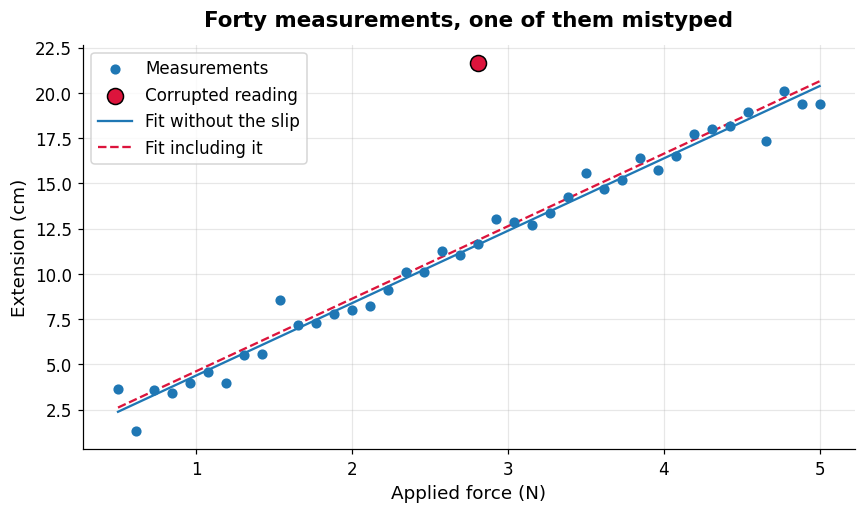

In [2]:
k_true, offset_true, noise_std = 25.0, 0.4, 0.6

force = np.linspace(0.5, 5.0, 40)
extension = (100.0 / k_true) * force + offset_true + rng.normal(0, noise_std, size=force.shape)

slip = 20                      # a point in the middle of the range, where leverage is lowest
extension_corrupt = extension.copy()
extension_corrupt[slip] += 10.0

X = force.reshape(-1, 1)
clean_model = LinearRegression().fit(X, extension)
dirty_model = LinearRegression().fit(X, extension_corrupt)

plt.figure(figsize=(8, 4.8))
plt.scatter(force, extension, s=32, label="Measurements", zorder=3)
plt.scatter(force[slip], extension_corrupt[slip], s=110, color="crimson",
            edgecolor="black", zorder=4, label="Corrupted reading")
plt.plot(force, clean_model.predict(X), label="Fit without the slip")
plt.plot(force, dirty_model.predict(X), color="crimson", linestyle="--",
         label="Fit including it")
plt.xlabel("Applied force (N)")
plt.ylabel("Extension (cm)")
plt.title("Forty measurements, one of them mistyped")
plt.legend()
plt.show()

## 2.1 Mean squared error, and its square root

The loss of `02A` was the **mean squared error**:

$$
\mathrm{MSE} \;=\; \frac{1}{n}\sum_{i=1}^{n}\bigl(y_i - \hat{y}_i\bigr)^2
$$

It has one awkward property as a *report*: its units are the square of the target's. For extension
in centimetres the MSE is in cm², which no experimentalist has intuition for. Taking the square
root fixes that, giving the **root mean squared error**, in centimetres again:

$$
\mathrm{RMSE} \;=\; \sqrt{\mathrm{MSE}}
$$

RMSE is the number to quote. MSE is the quantity to minimise, because the square root changes
nothing about where the minimum lies and only complicates the derivatives.

## 2.2 Mean absolute error

The obvious alternative measures the same errors without squaring them:

$$
\mathrm{MAE} \;=\; \frac{1}{n}\sum_{i=1}^{n}\bigl|y_i - \hat{y}_i\bigr|
$$

Also in centimetres, and readable as "the typical size of a miss". The difference between the two
is entirely in how they weigh a large error against several small ones.

The next cell reports RMSE and MAE for the fit, first on the clean measurements and then with the
mistyped one included.

1. Which of the two will grow more when the corrupted reading is added?
2. Roughly how large will the RMSE become, given that the slip is 10 cm?

**Think about your answer before running this cell.**

In [ ]:
for name, target, model in [("clean", extension, clean_model),
                            ("with the slip", extension_corrupt, dirty_model)]:
    predicted = model.predict(X)
    rmse = np.sqrt(mean_squared_error(target, predicted))
    mae = mean_absolute_error(target, predicted)
    print(f"{name:>14}:   RMSE {rmse:5.2f} cm     MAE {mae:5.2f} cm     ratio {rmse / mae:.2f}")

On clean data the two agree closely: the errors are all of a similar size, so squaring them changes
little, and the ratio sits near 1.

One corrupted point separates them. Squaring means a 10 cm error contributes a hundred times what a
1 cm error does, so it dominates the MSE and roughly doubles the RMSE. The MAE counts that error
once, in proportion to its size, and rises by well under half as much. Only one value in forty
changed.

That is not a defect in either. It is the choice:

- **RMSE** treats one large error as worse than several small ones. Right when large errors are
  disproportionately costly — a controller that must never overshoot badly.
- **MAE** treats errors in proportion to their size. Right when a miss of 10 costs ten times a miss
  of 1, and when the data may contain occasional bad values you do not want dominating the report.

A large RMSE-to-MAE ratio is itself informative: it says the errors are not all of a size, which
usually means a few observations are responsible for most of the loss. Worth looking at those
observations before reporting anything.

## 2.3 $R^2$, revisited

`02A` §7.4 introduced the **coefficient of determination**, and showed that a straight line fitted
to a visibly curved spring scored $R^2 = 0.9975$ while the correct model scored 0.9911. It is worth
restating why, now that we have alternatives to compare it against.

$$
R^2 \;=\; 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}
$$

RMSE and MAE report the size of the error in the target's own units. $R^2$ reports something else:
the error **relative to the variance of the target**. It answers "how much better than guessing the
mean is this?", not "how wrong is it?".

That makes it useful for comparing across datasets, and misleading in two ways worth knowing.

In [4]:
# The same model, judged on two datasets that differ only in the spread of the target
narrow_force = np.linspace(2.0, 2.5, 12)          # a narrow range of forces
wide_force = np.linspace(0.5, 20.0, 12)           # a wide one

print(f"{'force range':>14}{'RMSE':>10}{'R^2':>10}")
for name, f in [("narrow", narrow_force), ("wide", wide_force)]:
    y = (100.0 / k_true) * f + offset_true + rng.normal(0, noise_std, size=f.shape)
    m = LinearRegression().fit(f.reshape(-1, 1), y)
    print(f"{name:>14}{np.sqrt(mean_squared_error(y, m.predict(f.reshape(-1, 1)))):>10.3f}"
          f"{r2_score(y, m.predict(f.reshape(-1, 1))):>10.3f}")

   force range      RMSE       R^2
        narrow     0.437     0.671
          wide     0.593     0.999


The physics is identical in both rows and so is the instrument. The RMSE is comparable to the 0.6 cm
measurement error in both rows, which is what it should be — a little below it, as expected when
two parameters have been fitted to only twelve points, the `ddof` point from `02A` §7.2. The $R^2$ values are far apart.

Nothing is wrong. $R^2$ divides by the variance of the target, and over a wide range of forces the
extension varies much more, so the same absolute error accounts for a smaller share of it. **$R^2$
depends on the range over which you happened to sample**, which makes comparing $R^2$ between
experiments a trap unless the designs match.

The second warning is the one from `02A`: a high $R^2$ says the model captures much of the
variation, not that its shape is right. Residual plots answer that question; no single number does.

> Report RMSE or MAE when you want to say how wrong the model is. Report $R^2$ when you want to say
> how much of the variation it accounts for. They are different claims.

<div class="alert alert-success">
<b>Mini-exercise 1 — Choosing a regression metric</b><br>
For each situation, say which of RMSE, MAE and $R^2$ you would report, and why:
<br><br>
1. Calibrating a thermocouple, where the manufacturer quotes an accuracy in degrees.<br>
2. Comparing your model of a reaction yield against a published model, fitted to a different set of
   experiments.<br>
3. Predicting the settling time of a control system, where an occasional large overshoot damages
   equipment.<br>
4. A dataset in which about 2% of the recorded values are known to be transcription errors that you
   have not yet been able to identify.
</div>

In [5]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 3. Classification: why accuracy is not enough

`02B` §8 measured classifiers by **accuracy**, the fraction of predictions that were right, and
noted in passing that this is unsafe when one class is rare. That is worth doing properly, because
rare-event problems are the normal case in science: a detector searching for an uncommon decay, a
screen for an active compound, a survey looking for an unusual object.

We build one. A detector records two summary quantities per event, and about **2%** of events are
real signal.

In [6]:
n_events = 8000
signal_fraction = 0.02

is_signal = rng.random(n_events) < signal_fraction

# Two measured quantities; signal events sit slightly higher in both, with heavy overlap.
energy = rng.normal(loc=np.where(is_signal, 1.7, 0.0), scale=1.0)
timing = rng.normal(loc=np.where(is_signal, 1.2, 0.0), scale=1.0)

events = pd.DataFrame({"energy": energy, "timing": timing})
labels = is_signal.astype(int)

print(f"events:          {n_events}")
print(f"signal events:   {labels.sum()}  ({100 * labels.mean():.1f}%)")
print(f"background:      {n_events - labels.sum()}")

events:          8000
signal events:   183  (2.3%)
background:      7817


Consider the laziest possible detector: one that ignores both measurements and declares **every**
event to be background.

1. What accuracy does it achieve?
2. How many real signal events does it find?

**Think about your answer before running this cell.**

In [ ]:
always_background = np.zeros(n_events, dtype=int)

print(f"accuracy of 'everything is background': {accuracy_score(labels, always_background):.4f}")
print(f"signal events it finds:                 {always_background[labels == 1].sum()} of {labels.sum()}")

Ninety-eight per cent accurate, and completely worthless. It has never once done the thing the
detector exists to do.

This is the whole problem with accuracy on imbalanced data. It is dominated by the majority class,
so it rewards ignoring the minority — which is usually the class the experiment is about. Any
reported accuracy on an imbalanced problem should be read next to the majority-class baseline; if
it is not clearly better, it means nothing.

# 4. The confusion matrix

Accuracy collapses four different quantities into one. Separating them out is what the **confusion
matrix** does: it counts every combination of what was true and what was predicted.

|  | predicted background | predicted signal |
|---|---|---|
| **actually background** | true negative (TN) | false positive (FP) |
| **actually signal** | false negative (FN) | true positive (TP) |

The two errors have names worth using, because they are not interchangeable. A **false positive**
is a false alarm: background recorded as signal. A **false negative** is a miss: a real event
thrown away.

Which is worse depends entirely on the experiment, and no metric can tell you — you have to decide.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    events, labels, test_size=0.3, random_state=0, stratify=labels)

detector = LogisticRegression().fit(X_train, y_train)
predicted = detector.predict(X_test)

matrix = confusion_matrix(y_test, predicted)
(tn, fp), (fn, tp) = matrix

print(pd.DataFrame(matrix,
                   index=["actually background", "actually signal"],
                   columns=["predicted background", "predicted signal"]))
print(f"\naccuracy: {accuracy_score(y_test, predicted):.4f}")
print(f"majority-class baseline: {1 - y_test.mean():.4f}")

                     predicted background  predicted signal
actually background                  2338                 7
actually signal                        42                13

accuracy: 0.9796
majority-class baseline: 0.9771


Read the accuracy against the baseline underneath it. The model is barely distinguishable from
declaring everything background — and the confusion matrix shows why: it finds very few of the
signal events, because at the default threshold it is rarely confident enough to call one.

The matrix is the honest object. Everything below is a way of summarising it.

# 5. Precision and recall

Two summaries of the confusion matrix answer two different questions.

**Precision** — of the events I flagged as signal, what fraction really were?

$$
\text{precision} \;=\; \frac{TP}{TP + FP}
$$

**Recall** — of the real signal events, what fraction did I find?

$$
\text{recall} \;=\; \frac{TP}{TP + FN}
$$

Precision is about the purity of what you selected. Recall is about the completeness of the search.
Neither mentions the true negatives, and that is exactly why they survive imbalance: the great mass
of correctly ignored background events, which is what dominates the accuracy, appears in neither
formula.

In [9]:
print(f"precision: {precision_score(y_test, predicted, zero_division=0):.3f}"
      f"   = {tp} / ({tp} + {fp})")
print(f"recall:    {recall_score(y_test, predicted, zero_division=0):.3f}"
      f"   = {tp} / ({tp} + {fn})")
print(f"F1:        {f1_score(y_test, predicted, zero_division=0):.3f}")

precision: 0.650   = 13 / (13 + 7)
recall:    0.236   = 13 / (13 + 42)
F1:        0.347


## 5.1 $F_1$: one number from two

Reporting two numbers is often inconvenient, and the usual compromise is their **harmonic** mean:

$$
F_1 \;=\; 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}
$$

The harmonic mean rather than the ordinary one, because it refuses to be rescued by a single large
value. A model with precision 1.0 and recall 0.0 has an arithmetic mean of 0.5 and an $F_1$ of 0 —
which is the honest verdict on a detector that never fires.

$F_1$ is convenient and it hides the trade it summarises. Report it alongside precision and recall,
not instead of them.

# 6. The threshold is yours to choose

`02B` §7 set the decision threshold at 0.5 and noted that nothing forces that value. Here is where
that matters.

The model does not output a class; it outputs a probability. Turning it into a decision needs a
threshold, and the threshold is not part of the fit — it is a separate choice, made afterwards, and
it moves precision and recall in opposite directions.

The next cell recomputes precision and recall as the threshold is lowered from 0.5 towards 0.

1. Which of the two increases as the threshold falls?
2. What happens to each in the limit where the threshold reaches 0?

**Think about your answer before running this cell.**

In [ ]:
probabilities = detector.predict_proba(X_test)[:, 1]

print(f"{'threshold':>10}{'flagged':>9}{'precision':>11}{'recall':>9}{'F1':>7}")
for threshold in [0.50, 0.30, 0.20, 0.10, 0.05, 0.02, 0.01]:
    flagged = (probabilities >= threshold).astype(int)
    print(f"{threshold:>10.2f}{flagged.sum():>9}"
          f"{precision_score(y_test, flagged, zero_division=0):>11.3f}"
          f"{recall_score(y_test, flagged, zero_division=0):>9.3f}"
          f"{f1_score(y_test, flagged, zero_division=0):>7.3f}")

Lowering the threshold flags more events. That can only *increase* recall — a wider net catches more
of what it is looking for — and can only *decrease* precision, since the extra events flagged are
the ones the model was least sure about.

At threshold 0 everything is flagged: recall is 1.0, and precision falls to the signal fraction
itself, about 0.02. At a high threshold almost nothing is flagged: precision can be excellent and
recall near zero. **Neither extreme is a better model.** They are the same model, asked for
different trade-offs.

This is why quoting a single precision or recall without its threshold is meaningless, and why the
next two sections summarise the model *across all thresholds* instead.

<div class="alert alert-success">
<b>Mini-exercise 2 — Setting the threshold from the cost</b><br>
Two experiments use this same detector.
<br><br>
<b>Experiment A</b> can afford to inspect at most 100 candidate events by hand, and wants as many
real signals as possible among them.<br>
<b>Experiment B</b> is searching for evidence that the signal exists at all, and a single confirmed
event would be a result. Missing one is far worse than inspecting a few hundred background events.
<br><br>
1. Which of precision and recall matters more in each case?<br>
2. Using the table above, choose a threshold for each experiment and justify it in one sentence.<br>
3. For A, roughly how many real signal events would you expect to recover?
</div>

In [11]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 7. ROC and AUC

A curve is the natural object when a threshold has to be swept. Two are in common use, and they
answer different questions.

The **ROC curve** plots the true positive rate against the false positive rate as the threshold
moves across its whole range:

$$
\text{TPR} \;=\; \frac{TP}{TP + FN} \quad(\text{recall}), \qquad\qquad
\text{FPR} \;=\; \frac{FP}{FP + TN}
$$

Every point on it is one threshold. The top-left corner is perfection — everything found, nothing
falsely flagged. The diagonal is what random guessing achieves.

The area under that curve, the **AUC**, summarises the whole sweep in one number. It has a clean
interpretation: **the probability that the model gives a randomly chosen signal event a higher
score than a randomly chosen background event.** An AUC of 0.5 is guessing; 1.0 is a model that
ranks every signal above every background.

Note what that means — AUC judges the model's *ranking*, and is completely independent of the
threshold. It is the right summary when the threshold is still to be decided.

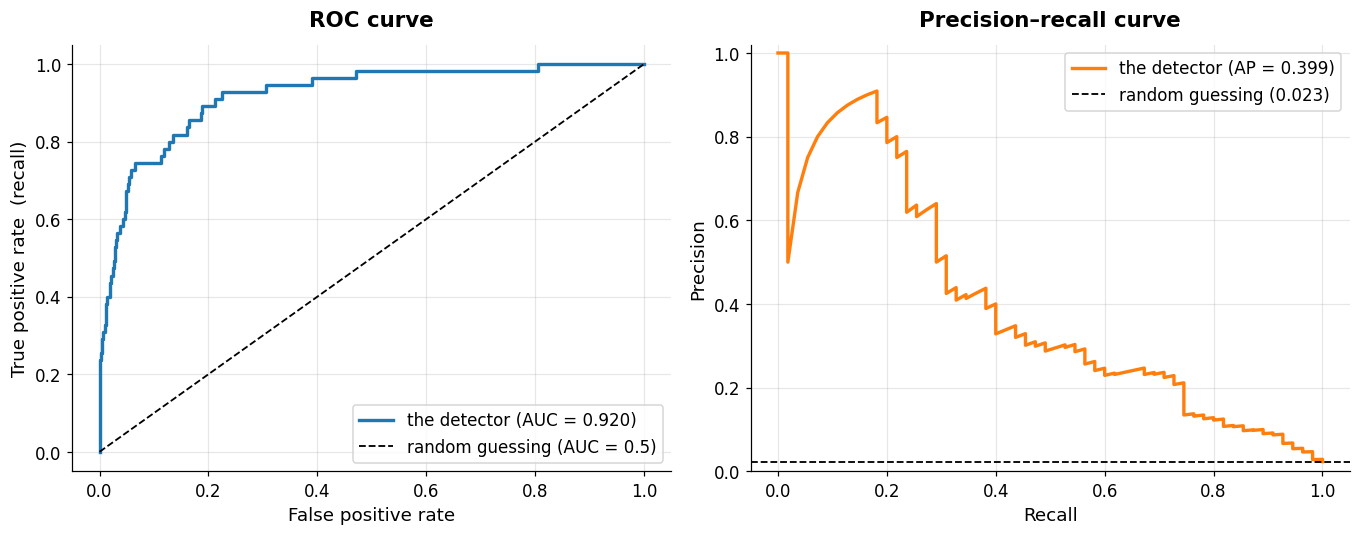

In [12]:
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
auc = roc_auc_score(y_test, probabilities)

precision_curve, recall_curve, _ = precision_recall_curve(y_test, probabilities)
average_precision = average_precision_score(y_test, probabilities)

fig, (roc_axis, pr_axis) = plt.subplots(1, 2, figsize=(12.5, 5))

roc_axis.plot(false_positive_rate, true_positive_rate, linewidth=2.2,
              label=f"the detector (AUC = {auc:.3f})")
roc_axis.plot([0, 1], [0, 1], "k--", linewidth=1.2, label="random guessing (AUC = 0.5)")
roc_axis.set_xlabel("False positive rate")
roc_axis.set_ylabel("True positive rate  (recall)")
roc_axis.set_title("ROC curve")
roc_axis.legend(loc="lower right")

pr_axis.plot(recall_curve, precision_curve, linewidth=2.2, color="tab:orange",
             label=f"the detector (AP = {average_precision:.3f})")
pr_axis.axhline(y_test.mean(), color="black", linestyle="--", linewidth=1.2,
                label=f"random guessing ({y_test.mean():.3f})")
pr_axis.set_xlabel("Recall")
pr_axis.set_ylabel("Precision")
pr_axis.set_ylim(0, 1.02)
pr_axis.set_title("Precision–recall curve")
pr_axis.legend(loc="upper right")

plt.show()

The two curves describe the same model and give very different impressions.

The ROC curve looks healthy, and its AUC is far above 0.5: the model genuinely does rank signal
above background most of the time. The precision–recall curve is far more sobering. Precision holds
up only while recall stays below roughly 0.2 — that is, while the detector confines itself to the
few events it is surest about — and falls away steadily after that.

Both are correct. The difference is what sits in the denominator. The false positive rate divides by
the number of background events, and there are thousands of them, so a few hundred false alarms
barely move it. Precision divides by the number of events *flagged*, where those same false alarms
dominate, because there were only tens of real signals to find.

> On heavily imbalanced problems the ROC curve flatters the model. The precision–recall curve, and
> its summary the **average precision**, describe what it will feel like to use.

Neither is wrong to report; reporting only the ROC on a rare-event problem is what misleads. Note
the baselines differ too: random guessing gives AUC 0.5 on the ROC, but precision equal to the
signal fraction — here about 0.02 — on the precision–recall curve.

# 8. Choosing a metric

There is no default. The choice follows from the costs, and stating those costs is a scientific
judgement rather than a statistical one.

| Situation | Report |
|---|---|
| Regression, errors in physical units, occasional bad data | MAE |
| Regression, large errors disproportionately costly | RMSE |
| Regression, comparing against a model fitted elsewhere | $R^2$, with the sampling range stated |
| Classification, balanced classes, errors equally costly | accuracy |
| Classification, rare positives, false alarms expensive | precision, at a stated threshold |
| Classification, rare positives, misses expensive | recall, at a stated threshold |
| Classification, threshold not yet decided | AUC for ranking, average precision if rare |

Two habits are worth more than any of these entries. **State the threshold** whenever you quote a
precision or a recall, since neither means anything without it. And **quote the baseline** next to
any accuracy — the majority-class rate — so a reader can see at a glance whether the model has done
anything at all.

# 9. Common pitfalls

**Reporting accuracy on imbalanced data.** The one this notebook opened with. 98% accuracy on a 2%
problem is what you get for doing nothing.

**Quoting precision or recall without a threshold.** Either can be driven to almost any value by
moving it. The pair, at a stated threshold, is a claim; one of them alone is not.

**Optimising $F_1$ because it is a single number.** It weights precision and recall equally, which
is a real assumption about costs and is usually made by accident rather than on purpose.

**Reading AUC as accuracy.** An AUC of 0.9 does not mean 90% of predictions are right. It means
that given one signal and one background event, the model ranks them correctly 90% of the time.

**Reporting the ROC alone on a rare-event problem.** As section 7 showed, it can look excellent
while the model is unusable at every threshold.

**Choosing the metric after seeing the results.** Trying several and reporting the flattering one is
the same failure as choosing a model on the test set, one notebook earlier. Decide the metric from
the costs, before fitting.

# 10. Final exercises

<div class="alert alert-success">
<b>Exercise 1 — A full evaluation</b><br>
Refit the detector of section 3 and produce a complete evaluation of it:
<br><br>
1. the confusion matrix at threshold 0.5, and the majority-class baseline;<br>
2. precision, recall and $F_1$ at that threshold;<br>
3. the threshold that maximises $F_1$ on the test set, found by sweeping;<br>
4. the AUC and the average precision;<br>
5. three sentences a collaborator could read, stating what the detector does and at what cost.
<br><br>
<b>To check yourself:</b> the best $F_1$ threshold should come out well below 0.5.
</div>

In [13]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — When the classes are balanced</b><br>
Repeat the analysis of sections 3 to 7 with <code>signal_fraction = 0.5</code> instead of 0.02,
leaving everything else unchanged.
<br><br>
1. How far apart are the accuracy and the majority-class baseline now?<br>
2. How do the ROC and precision–recall curves compare with the imbalanced case?<br>
3. Which of the two curves changed more, and why?<br>
4. What does this suggest about when the distinction between them matters?
</div>

In [14]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Cost-weighted decisions</b><br>
Suppose a false negative costs 20 times what a false positive costs.
<br><br>
1. Write a function that, given true labels, predicted probabilities and a threshold, returns the
   total cost.<br>
2. Sweep the threshold and find the cost-minimising value.<br>
3. Compare it with the threshold that maximises $F_1$. Are they the same? Should they be?<br>
4. What would the cost-minimising threshold be if the two errors cost the same?
</div>

In [15]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- A metric is a statement about which mistakes matter. Choose it from the costs, before fitting.
- RMSE and MAE report error in the target's units; they differ in how much weight a single large
  error carries. Their ratio indicates whether a few observations dominate the loss.
- $R^2$ measures error relative to the variance of the target, so it depends on the range sampled
  and cannot be compared across differently designed experiments.
- Accuracy is dominated by the majority class. On a 2% problem, doing nothing scores 98%.
- The confusion matrix is the honest object; precision, recall and $F_1$ are summaries of it, and
  none of them mentions the true negatives, which is why they survive imbalance.
- The threshold is a free parameter, chosen after fitting. Precision and recall move in opposite
  directions as it moves, so neither means anything unless the threshold is stated.
- AUC summarises the ranking across all thresholds; on rare-event problems the precision–recall
  curve describes the experience of using the model far better than the ROC does.

# Optional preparation for the next notebook

Before the next notebook, students should be comfortable with:

- computing RMSE, MAE and $R^2$, and saying which is appropriate;
- reading a confusion matrix and deriving precision and recall from it;
- explaining why accuracy fails on imbalanced data;
- describing what moving the decision threshold does.

`03B` returns to the U-shaped test-error curve of `02C` and asks why it has that shape. The answer
splits a model's error into three parts — one from being too rigid, one from being too sensitive to
the particular data, and one that no model can remove. The last of those is the floor that `02B`
§10.5 ran into, where two species overlap and no boundary can separate them.